# Smart Water Consumption Monitoring & Leakage Detetion

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached pandas-3.0.0-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.1-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using 


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
df = pd.read_csv("../data/water_consumption.csv", parse_dates=["date"])
df.head()


,date,household_id,daily_consumption_liters,pressure_psi,temperature_c,rainfall_mm,population_density
0,2024-01-01,H1000,409.605698,56.630888,33.597422,0.628930,2000
1,2024-01-02,H1001,333.408284,61.547083,31.698535,3.486503,3500
2,2024-01-03,H1002,427.722625,45.007162,28.238521,1.379329,3500
3,2024-01-04,H1003,532.763583,54.814846,25.412253,0.160378,2500
4,2024-01-05,H1004,321.901595,48.746787,30.792893,0.120670,3500


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      500 non-null    datetime64[us]
 1   household_id              500 non-null    str           
 2   daily_consumption_liters  500 non-null    float64       
 3   pressure_psi              500 non-null    float64       
 4   temperature_c             500 non-null    float64       
 5   rainfall_mm               500 non-null    float64       
 6   population_density        500 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 27.5 KB


In [5]:
df.describe()

,date,daily_consumption_liters,pressure_psi,temperature_c,rainfall_mm,population_density
count,500,500.000000,500.000000,500.000000,500.000000,500.00000
mean,2024-09-06 12:00:00,398.242088,51.218385,28.433938,1.931037,2738.00000
min,2024-01-01 00:00:00,80.000000,35.083199,16.414978,0.003133,2000.00000
25%,2024-05-04 18:00:00,271.756092,47.985216,25.590282,0.597803,2000.00000
50%,2024-09-06 12:00:00,359.190372,51.738668,28.479223,1.349104,2750.00000
75%,2025-01-09 06:00:00,447.562880,55.059616,31.018953,2.669149,3000.00000
max,2025-05-14 00:00:00,1192.147496,65.000000,38.406732,12.810946,3500.00000
std,NaN,206.986676,5.766745,4.040985,1.885506,566.56685


In [6]:
df.isnull().sum()

date                        0
household_id                0
daily_consumption_liters    0
pressure_psi                0
temperature_c               0
rainfall_mm                 0
population_density          0
dtype: int64

In [7]:
# Remove duplicates if any
df.drop_duplicates(inplace=True)


In [8]:
df["leak_detected"] = np.where(
    (df["daily_consumption_liters"] > 700) | (df["pressure_psi"] < 48),
    1,
    0
)

df.head()


,date,household_id,daily_consumption_liters,pressure_psi,temperature_c,rainfall_mm,population_density,leak_detected
0,2024-01-01,H1000,409.605698,56.630888,33.597422,0.628930,2000,0
1,2024-01-02,H1001,333.408284,61.547083,31.698535,3.486503,3500,0
2,2024-01-03,H1002,427.722625,45.007162,28.238521,1.379329,3500,1
3,2024-01-04,H1003,532.763583,54.814846,25.412253,0.160378,2500,0
4,2024-01-05,H1004,321.901595,48.746787,30.792893,0.120670,3500,0


In [9]:
df.groupby("household_id")["daily_consumption_liters"].mean()


household_id
H1000    366.547250
H1001    375.824543
H1002    464.637709
H1003    405.828905
H1004    314.136232
H1005    485.908230
H1006    426.300837
H1007    437.450359
H1008    404.250632
H1009    537.152490
H1010    380.816128
H1011    440.371769
H1012    320.495256
H1013    360.403456
H1014    474.110522
H1015    346.037528
H1016    454.676959
H1017    361.453318
H1018    564.417180
H1019    347.484457
H1020    620.322751
H1021    378.608288
H1022    374.907037
H1023    384.401803
H1024    408.401226
H1025    405.674929
H1026    400.809043
H1027    455.456038
H1028    545.758595
H1029    440.067194
H1030    490.624572
H1031    377.989718
H1032    314.466139
H1033    390.951506
H1034    399.321622
H1035    324.540115
H1036    339.627486
H1037    324.105171
H1038    338.901166
H1039    362.658380
H1040    329.255646
H1041    504.655674
H1042    285.670295
H1043    354.795175
H1044    333.754509
H1045    393.654157
H1046    281.689534
H1047    333.459277
H1048    365.416750
H1049  

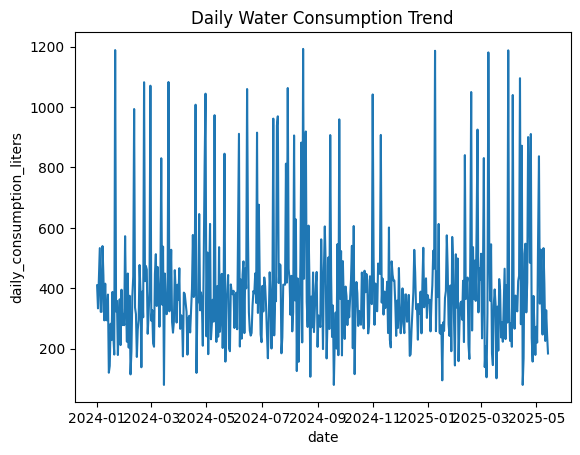

In [10]:
plt.figure()
sns.lineplot(data=df, x="date", y="daily_consumption_liters")
plt.title("Daily Water Consumption Trend")
plt.show()


In [11]:
df["leak_detected"].value_counts()


leak_detected
0    374
1    126
Name: count, dtype: int64

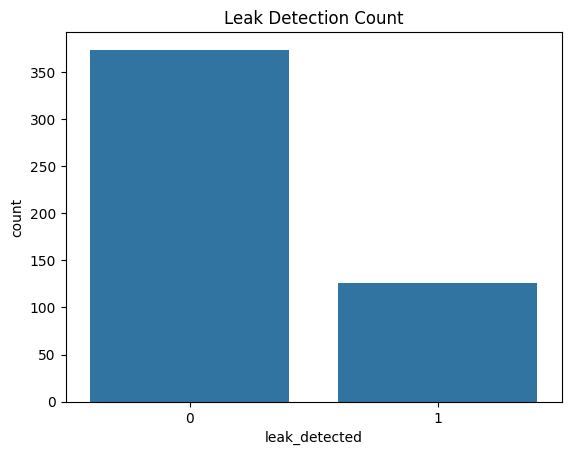

In [12]:
plt.figure()
sns.countplot(x="leak_detected", data=df)
plt.title("Leak Detection Count")
plt.show()


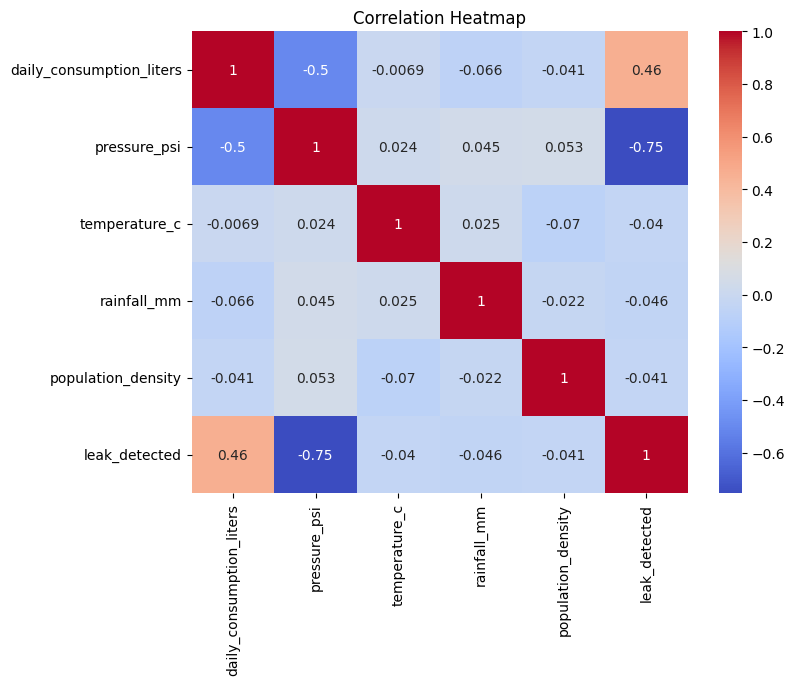

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [14]:
X = df[
    ["daily_consumption_liters", "pressure_psi", "temperature_c",
     "rainfall_mm", "population_density"]
]

y = df["leak_detected"]


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = model.predict(X_test)


In [18]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 0.09246343975605212
R2 Score: 0.4930732469514687


In [19]:
df["leak_risk_score"] = model.predict(X)
df[["household_id", "date", "leak_risk_score"]].head()


,household_id,date,leak_risk_score
0,H1000,2024-01-01,-0.064351
1,H1001,2024-01-02,-0.345701
2,H1002,2024-01-03,0.580622
3,H1003,2024-01-04,0.075732
4,H1004,2024-01-05,0.334000


In [21]:
#save the model
import joblib
joblib.dump(model, "../model/water_leak_detection_model.pkl")

['../model/water_leak_detection_model.pkl']